Assignment for day 1
1. Install miniconda if required (https://docs.conda.io/en/latest/miniconda.html)
2. Install conda environment by running: conda env create -f environment.yml
3. Verify environment is activated and run this notebook
* either in the IDE
* or by running a jupyter server on localhost: jupyter notebook --ip=0.0.0.0

In [1]:
# imports
import yfinance as yf

In [2]:
# parameters
TICKERS = ["AAPL", "GOOGL", "MSFT"]
START_DATE = "2025-01-01"
END_DATE = "2026-02-27"

In [3]:
# download OHLCV data for tickers
print(f"Downloading data for: {', '.join(TICKERS)}")
prices = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
# auto_adjust: adjust prices for price actions. Recommended for clean prices.

prices.head()

/opt/miniconda3/envs/algotrading/lib/python3.11/site-packages/yfinance/scrapers/history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL       GOOGL        MSFT        AAPL       GOOGL   
Date                                                                     
2025-01-02  242.525177  188.691010  414.568604  247.746654  191.250991   
2025-01-03  242.037827  191.041779  419.292877  242.853364  192.456252   
2025-01-06  243.668915  196.101990  423.749756  245.986258  197.446729   
2025-01-07  240.894058  194.727371  418.322296  244.215908  200.215870   
2025-01-08  241.381393  193.193375  420.491272  242.385916  195.524242   

Price                          Low                                Open  \
Ticker            MSFT        AAPL       GOOGL        MSFT        AAPL   
Date                                                                     
2025-01-02  421.986845  240.506207  186.768546  410.874369  247.577564   
2025-01-03  419.966353  240.575812  189.238842  415.519392  242.037827   
2025-01-06  430.157753  241.878691  193.093782  421.402473  242.982661   
2025-01-07  426.522945  240.038730  193.840844  416.767335  241.659864   
2025-01-08  422.878180  238.745797  191.629507  417.500225  240.605632   

Price                                 Volume                      
Ticker           GOOGL        MSFT      AAPL     GOOGL      MSFT  
Date                                                              
2025-01-02  189.906251  421.452012  55740700  20370800  16896500  
2025-01-03  190.623419  417.044612  40244100  18596200  16662900  
2025-01-06  193.223264  423.898312  45045600  29563600  20573600  
2025-01-07  196.341047  424.888764  40856000  26487200  18139100  
2025-01-08  191.818769  419.401808  37628900  24864800  15054600

In [4]:
# extract close prices
close = prices["Close"]
close.columns.name = None  # remove the "Close" multi-index
close.head()


,AAPL,GOOGL,MSFT
Date,,,
2025-01-02,242.525177,188.691010,414.568604
2025-01-03,242.037827,191.041779,419.292877
2025-01-06,243.668915,196.101990,423.749756
2025-01-07,240.894058,194.727371,418.322296
2025-01-08,241.381393,193.193375,420.491272


In [5]:
# run quick statistics
close.describe().round(2)

,AAPL,GOOGL,MSFT
count,288.00,288.00,288.00
mean,235.72,225.40,458.19
std,27.16,61.43,49.82
min,171.67,144.30,351.87
25%,210.76,172.40,410.66
50%,234.72,198.30,473.33
75%,259.79,284.23,503.09
max,285.92,343.69,539.83


<Axes: xlabel='Date'>

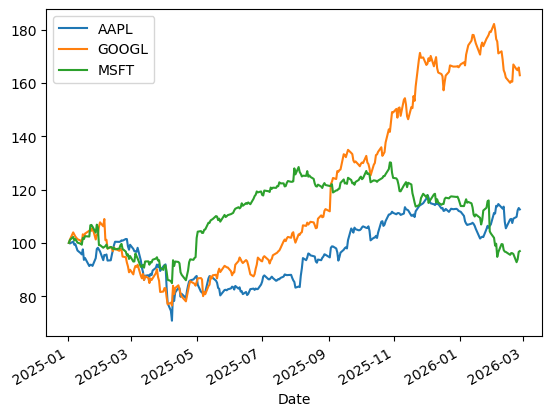

In [6]:
# normalize to 100 at start
df_normalized = (close / close.iloc[0]) * 100

# plot normalized close prices
df_normalized.plot()
